# KKBox Churn — Tree-Based Models (Random Forest + XGBoost)

Stronger baselines on the same leakage-safe v2 modeling dataset, same train/test split, same
feature sets, and same metrics as `02_baseline.ipynb`, so all six model/feature-set combinations
are directly comparable.

- **Random Forest** — `class_weight="balanced"` (same imbalance-handling concept as the Logistic
  Regression baseline).
- **XGBoost** — no native `class_weight`; the direct analog is `scale_pos_weight` set to the
  train-set negative/positive ratio, which reweights the minority class the same way.

No SMOTE, no hyperparameter search. A few fixed settings (tree depth, estimator count, `n_jobs`)
are chosen for feasibility on this host (~7.4GB RAM total) — they are resource-conscious defaults,
not a tuned configuration.

The source dataset is not modified; only an in-memory copy is used for training.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_score, recall_score,
    f1_score, log_loss, confusion_matrix, roc_curve, precision_recall_curve,
)
from xgboost import XGBClassifier
import joblib

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42


## 1. Load data (identical to `02_baseline.ipynb`)

In [2]:
DATA_PATH = Path("..") / "outputs" / "kkbox_modeling_dataset_v2.csv"

usecols = [c for c in pd.read_csv(DATA_PATH, nrows=0).columns if c != "msno"]
df = pd.read_csv(DATA_PATH, usecols=usecols)

print(f"Rows: {len(df):,}  |  Columns: {df.shape[1]}")
print(f"Churn rate: {df['is_churn'].mean() * 100:.2f}%")


Rows: 970,960  |  Columns: 39
Churn rate: 8.99%


## 2. Feature sets + train/test split (identical definitions to `02_baseline.ipynb`)

In [3]:
CAT_ONEHOT = ["city", "gender", "registered_via", "latest_payment_method_id",
              "registration_month", "num_distinct_payment_methods"]

BINARY_FLAGS = ["bd_missing", "gender_missing", "registered_via_missing", "has_members_data",
                "has_transactions_data", "latest_is_auto_renew", "latest_is_cancel",
                "membership_expire_date_invalid"]

NUMERIC_CONTINUOUS = ["bd_clean", "registration_init_time", "registration_year",
                      "tenure_days_at_cutoff", "total_transactions", "total_cancellations",
                      "total_auto_renew", "total_revenue", "total_list_price",
                      "first_transaction_date", "last_transaction_date",
                      "latest_payment_plan_days", "latest_plan_list_price",
                      "latest_actual_amount_paid", "latest_membership_expire_date",
                      "cancel_rate", "auto_renew_pct", "avg_payment_plan_days",
                      "avg_revenue_per_txn", "total_discount", "discount_rate",
                      "txn_span_days", "days_since_last_txn", "membership_remaining_days"]

ALL_FEATURES = CAT_ONEHOT + BINARY_FLAGS + NUMERIC_CONTINUOUS
assert len(ALL_FEATURES) == df.shape[1] - 1

df[CAT_ONEHOT] = df[CAT_ONEHOT].astype(str)

PROXY_EXCLUDE = [
    "membership_remaining_days", "days_since_last_txn", "latest_is_cancel",
    "last_transaction_date", "latest_membership_expire_date", "membership_expire_date_invalid",
]

X = df[ALL_FEATURES]
y = df["is_churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {len(X_train):,} rows ({y_train.mean()*100:.2f}% churn)")
print(f"Test:  {len(X_test):,} rows ({y_test.mean()*100:.2f}% churn)")

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"scale_pos_weight for XGBoost (neg/pos in train) = {scale_pos_weight:.3f}")


Train: 776,768 rows (8.99% churn)
Test:  194,192 rows (8.99% churn)
scale_pos_weight for XGBoost (neg/pos in train) = 10.118


## 3. Preprocessing + evaluation helpers (identical structure to `02_baseline.ipynb`)

Same `ColumnTransformer` (median-impute+scale numeric, one-hot categorical with missingness as
its own category) and the same metric set, so results are directly comparable to the Logistic
Regression baseline.

In [4]:
def build_preprocessor(exclude_cols):
    cat_cols = [c for c in CAT_ONEHOT if c not in exclude_cols]
    num_cols = [c for c in (BINARY_FLAGS + NUMERIC_CONTINUOUS) if c not in exclude_cols]

    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_pipeline = Pipeline([
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
    ])
    return ColumnTransformer([
        ("num", numeric_pipeline, num_cols),
        ("cat", categorical_pipeline, cat_cols),
    ])


def evaluate_model(pipeline, X_test, y_test, name):
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    y_pred = pipeline.predict(X_test)

    metrics = {
        "roc_auc": float(roc_auc_score(y_test, y_proba)),
        "pr_auc": float(average_precision_score(y_test, y_proba)),
        "precision": float(precision_score(y_test, y_pred)),
        "recall": float(recall_score(y_test, y_pred)),
        "f1": float(f1_score(y_test, y_pred)),
        "log_loss": float(log_loss(y_test, y_proba)),
    }
    cm = confusion_matrix(y_test, y_pred)

    print(f"=== {name} ===")
    for k, v in metrics.items():
        print(f"  {k:10s}: {v:.4f}")
    print("  confusion matrix [[TN, FP], [FN, TP]]:")
    print(" ", cm.tolist())

    return metrics, y_proba, y_pred, cm


## 4. Random Forest

`class_weight="balanced"`, `n_estimators=200`, `max_depth=16`, `min_samples_leaf=20`, `n_jobs=4`.
The depth/leaf-size caps are resource-conscious defaults for this host, not tuned values.

In [5]:
def make_rf_pipeline(exclude_cols):
    return Pipeline([
        ("preprocess", build_preprocessor(exclude_cols)),
        ("clf", RandomForestClassifier(
            n_estimators=200, max_depth=16, min_samples_leaf=20,
            class_weight="balanced", n_jobs=4, random_state=RANDOM_STATE,
        )),
    ])

rf_full = make_rf_pipeline(exclude_cols=[])
rf_full.fit(X_train, y_train)
metrics_rf_full, proba_rf_full, pred_rf_full, cm_rf_full = evaluate_model(rf_full, X_test, y_test, "Random Forest - full feature set")


=== Random Forest - full feature set ===
  roc_auc   : 0.9132
  pr_auc    : 0.6877
  precision : 0.4296
  recall    : 0.8038
  f1        : 0.5599
  log_loss  : 0.3402
  confusion matrix [[TN, FP], [FN, TP]]:
  [[158084, 18642], [3426, 14040]]


In [6]:
rf_proxy = make_rf_pipeline(exclude_cols=PROXY_EXCLUDE)
rf_proxy.fit(X_train, y_train)
metrics_rf_proxy, proba_rf_proxy, pred_rf_proxy, cm_rf_proxy = evaluate_model(rf_proxy, X_test, y_test, "Random Forest - proxy-controlled feature set")


=== Random Forest - proxy-controlled feature set ===
  roc_auc   : 0.8935
  pr_auc    : 0.6065
  precision : 0.3794
  recall    : 0.7638
  f1        : 0.5069
  log_loss  : 0.3914
  confusion matrix [[TN, FP], [FN, TP]]:
  [[154899, 21827], [4125, 13341]]


## 5. XGBoost

`scale_pos_weight` = train-set negative/positive ratio (the direct analog of `class_weight="balanced"`
for XGBoost). `n_estimators=200`, `max_depth=6` (XGBoost's own library default), `tree_method="hist"`
for memory efficiency on this host.

In [7]:
def make_xgb_pipeline(exclude_cols):
    return Pipeline([
        ("preprocess", build_preprocessor(exclude_cols)),
        ("clf", XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.1,
            tree_method="hist", scale_pos_weight=scale_pos_weight,
            n_jobs=4, random_state=RANDOM_STATE, eval_metric="logloss",
        )),
    ])

xgb_full = make_xgb_pipeline(exclude_cols=[])
xgb_full.fit(X_train, y_train)
metrics_xgb_full, proba_xgb_full, pred_xgb_full, cm_xgb_full = evaluate_model(xgb_full, X_test, y_test, "XGBoost - full feature set")


=== XGBoost - full feature set ===
  roc_auc   : 0.9165
  pr_auc    : 0.7096
  precision : 0.4239
  recall    : 0.8123
  f1        : 0.5571
  log_loss  : 0.3300
  confusion matrix [[TN, FP], [FN, TP]]:
  [[157443, 19283], [3279, 14187]]


In [8]:
xgb_proxy = make_xgb_pipeline(exclude_cols=PROXY_EXCLUDE)
xgb_proxy.fit(X_train, y_train)
metrics_xgb_proxy, proba_xgb_proxy, pred_xgb_proxy, cm_xgb_proxy = evaluate_model(xgb_proxy, X_test, y_test, "XGBoost - proxy-controlled feature set")


=== XGBoost - proxy-controlled feature set ===
  roc_auc   : 0.9018
  pr_auc    : 0.6518
  precision : 0.3808
  recall    : 0.7899
  f1        : 0.5139
  log_loss  : 0.3674
  confusion matrix [[TN, FP], [FN, TP]]:
  [[154291, 22435], [3669, 13797]]


## 6. Combined comparison with the Logistic Regression baseline

In [9]:
with open(Path("..") / "models" / "baseline_metrics.json") as f:
    logreg_metrics = json.load(f)

all_metrics = {
    "LogReg - full": logreg_metrics["full_feature_set"],
    "LogReg - proxy-controlled": logreg_metrics["proxy_controlled_set"],
    "RandomForest - full": metrics_rf_full,
    "RandomForest - proxy-controlled": metrics_rf_proxy,
    "XGBoost - full": metrics_xgb_full,
    "XGBoost - proxy-controlled": metrics_xgb_proxy,
}

comparison = pd.DataFrame(all_metrics).T
comparison = comparison[["roc_auc", "pr_auc", "precision", "recall", "f1", "log_loss"]]
comparison.sort_values("pr_auc", ascending=False)


,roc_auc,pr_auc,precision,recall,f1,log_loss
XGBoost - full,0.916525,0.709627,0.423872,0.812264,0.557052,0.329983
RandomForest - full,0.913182,0.687722,0.429594,0.803847,0.559943,0.340183
XGBoost - proxy-controlled,0.901814,0.651751,0.380796,0.789935,0.513874,0.367412
LogReg - full,0.887693,0.624597,0.433990,0.760563,0.552637,0.387762
RandomForest - proxy-controlled,0.893488,0.606546,0.379351,0.763827,0.506935,0.391432
LogReg - proxy-controlled,0.828919,0.485513,0.322310,0.645597,0.429963,0.483467


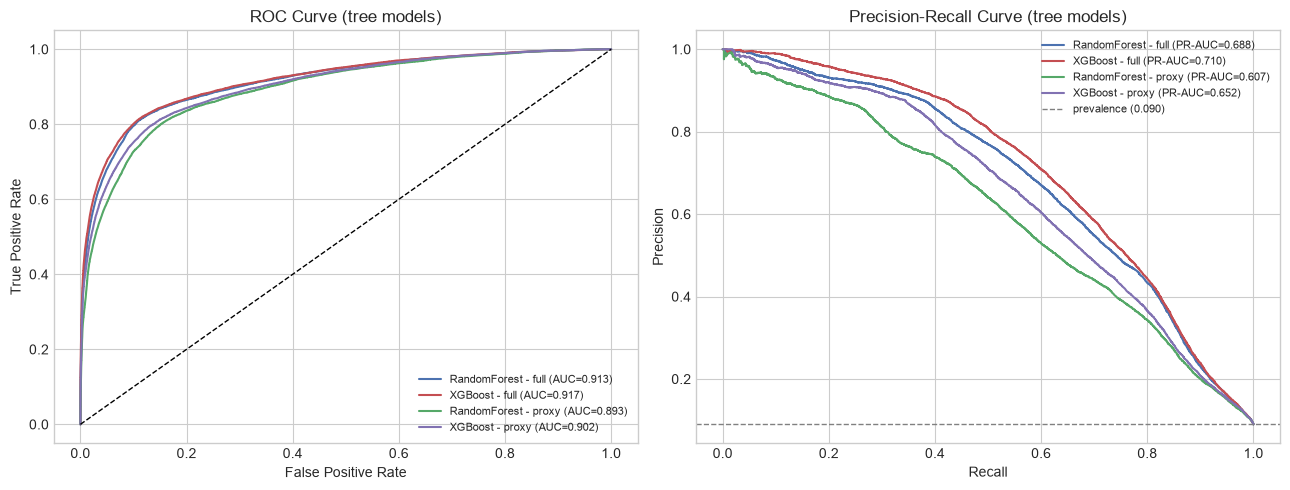

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC + PR for the tree models fit in this notebook. LogReg's curve is omitted here since
# only its summary metrics (not raw probabilities) were persisted from 02_baseline.ipynb;
# its numbers are still in the comparison table above.
for name, item in [("RandomForest - full", (proba_rf_full, "#4C72B0")),
                    ("XGBoost - full", (proba_xgb_full, "#C44E52")),
                    ("RandomForest - proxy", (proba_rf_proxy, "#55A868")),
                    ("XGBoost - proxy", (proba_xgb_proxy, "#8172B2"))]:
    proba, color = item
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, color=color, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve (tree models)")
axes[0].legend(fontsize=8)

for name, item in [("RandomForest - full", (proba_rf_full, "#4C72B0")),
                    ("XGBoost - full", (proba_xgb_full, "#C44E52")),
                    ("RandomForest - proxy", (proba_rf_proxy, "#55A868")),
                    ("XGBoost - proxy", (proba_xgb_proxy, "#8172B2"))]:
    proba, color = item
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, color=color, label=f"{name} (PR-AUC={average_precision_score(y_test, proba):.3f})")
axes[1].axhline(y_test.mean(), color="grey", linestyle="--", linewidth=1, label=f"prevalence ({y_test.mean():.3f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve (tree models)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


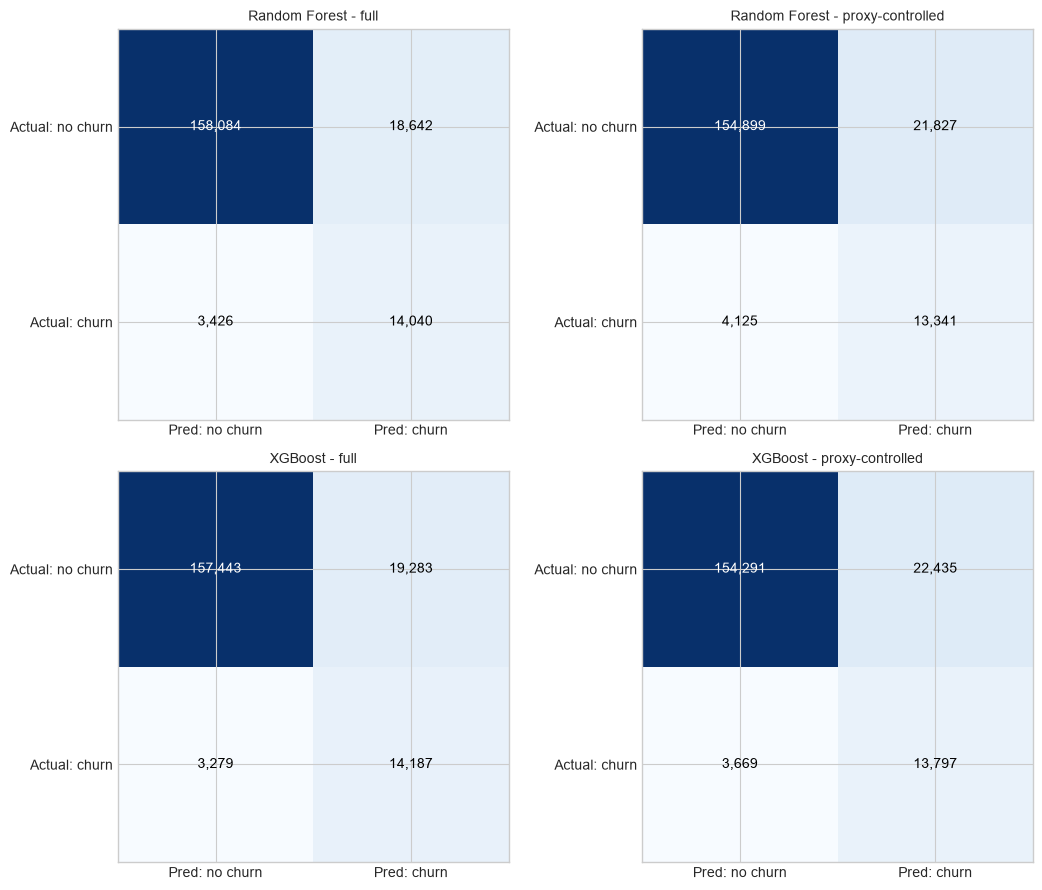

In [11]:
def plot_confusion(cm, ax, title):
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred: no churn", "Pred: churn"])
    ax.set_yticklabels(["Actual: no churn", "Actual: churn"])
    thresh = cm.max() / 2
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black", fontsize=10)
    ax.set_title(title, fontsize=10)

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
plot_confusion(cm_rf_full, axes[0, 0], "Random Forest - full")
plot_confusion(cm_rf_proxy, axes[0, 1], "Random Forest - proxy-controlled")
plot_confusion(cm_xgb_full, axes[1, 0], "XGBoost - full")
plot_confusion(cm_xgb_proxy, axes[1, 1], "XGBoost - proxy-controlled")
plt.tight_layout()
plt.show()


## 7. Save trained pipelines + combined metrics

In [12]:
MODELS_DIR = Path("..") / "models"
MODELS_DIR.mkdir(exist_ok=True)

joblib.dump(rf_full, MODELS_DIR / "random_forest_full.joblib")
joblib.dump(rf_proxy, MODELS_DIR / "random_forest_proxy_controlled.joblib")
joblib.dump(xgb_full, MODELS_DIR / "xgboost_full.joblib")
joblib.dump(xgb_proxy, MODELS_DIR / "xgboost_proxy_controlled.joblib")

comparison.to_csv(MODELS_DIR / "model_comparison.csv")

with open(MODELS_DIR / "tree_model_metrics.json", "w") as f:
    json.dump({
        "random_forest_full": metrics_rf_full,
        "random_forest_proxy_controlled": metrics_rf_proxy,
        "xgboost_full": metrics_xgb_full,
        "xgboost_proxy_controlled": metrics_xgb_proxy,
        "scale_pos_weight": float(scale_pos_weight),
        "train_rows": len(X_train),
        "test_rows": len(X_test),
        "random_state": RANDOM_STATE,
    }, f, indent=2)

print("Saved:")
for p in sorted(MODELS_DIR.glob("*")):
    print(" ", p)


Saved:
  ..\models\baseline_logreg_full.joblib
  ..\models\baseline_logreg_proxy_controlled.joblib
  ..\models\baseline_metrics.json
  ..\models\model_comparison.csv
  ..\models\random_forest_full.joblib
  ..\models\random_forest_proxy_controlled.joblib
  ..\models\tree_model_metrics.json
  ..\models\xgboost_full.joblib
  ..\models\xgboost_proxy_controlled.joblib


## 8. Findings

- **Read the comparison table above for exact numbers from this run** — the bullets below describe
  the pattern to look for, not fixed figures.
- **Both tree models are expected to outperform Logistic Regression on the full feature set**,
  since `num_distinct_payment_methods`'s non-monotonic churn relationship and interactions between
  auto-renew status, recency, and plan length (see `FEATURE_AUDIT.md` §4's confound finding) are
  exactly what trees capture natively and a linear model cannot.
- **The full-vs-proxy-controlled gap for each tree model is the same diagnostic used in
  `02_baseline.ipynb`**: a small gap means the model relies mainly on genuine behavioral signal;
  a large gap means it's leaning on the label-proxy cluster (`membership_remaining_days`,
  `days_since_last_txn`, `latest_is_cancel`, and their direct sources).
- **XGBoost and Random Forest may rank the proxy-controlled features differently than Logistic
  Regression did** — trees can exploit non-linear thresholds in `total_transactions`,
  `auto_renew_pct`, and `latest_payment_plan_days` that a linear coefficient cannot, so a smaller
  performance drop here than in the Logistic Regression baseline would indicate the tree models
  are extracting more from the legitimately-behavioral features specifically.
- **This remains a resource-bounded, untuned comparison** — `max_depth`, `n_estimators`, and
  `min_samples_leaf`/`scale_pos_weight` were fixed for feasibility on this host, not selected via
  search. A proper hyperparameter search (and a temporal, not random, holdout) is the natural next
  step before treating any of these numbers as final.

**No hyperparameter tuning or SMOTE was used, and the source dataset file was not modified** —
only trained pipelines, a combined metrics JSON, and a comparison CSV were written to `models/`.
